# **ResNet-50 Feature Extraction + SVM**
*Created and runned with Google Colab*

This code has to be executed BEFORE the other notebook, follow the numeration. \
**Dataset**: *Rare Neurological Diseases MRI - curated ver*, from [Kaggle](https://www.kaggle.com/datasets/ahsanneural/rare-neurological-diseases-mri-curated-edition)

> This dataset is derived from the *"Benchmark Diagnostic MRI and Medical Imaging Dataset"* published on Mendeley Data by *Haseeb Hassan, M. Usman Akram, Waqas Ahmad, and Sajid Gul Khawaja (2024)*, available at this link [Mendeley Data](https://data.mendeley.com/datasets/d73rs38yk6/1)

**Strategy 1 of the comparison: classical feature extraction** \
The ImageNet ResNet-50 is used as a
frozen feature extractor — the classification head is replaced by `nn.Identity()`, so each image
becomes a 2048-D vector — and a linear SVM is trained on those vectors. The backbone is never
trained on MRI: no weights change, no labels are seen.

*Notebook 02* runs the other strategy (ConvNeXt-Tiny fine-tuned end-to-end) on the same data, the same splits and the same seed, so the two are directly comparable


## **1) Drive mount & Kaggle dataset's download**


In order to correctly configure the project, in your drive there must be the folder for the project, in my case is inside the folder I use for my University projects.
Plus, to download the dataset directly from Kaggle (to have the last version), it is required to copy an info from your Kaggle's account as follows:
- Go to [Kaggle' site](https://www.kaggle.com/) and log in it
- By intercat with your profile photo on the top-right, go to `Settings`
- Search for the section `API` and `Generate New Token`, it will open a pop up with some info:
  - **API TOKEN** (`KGAT_...`): This is your unique password. Copy it now, because Kaggle will never show it to you again

  - **Option 1** (`export KAGGLE_API_TOKEN=...`): It is used to save the token as a temporary environment variable in the terminal Linux/Mac.

  - **Option 2** (`mkdir -p ~/.kaggle && echo ...`): It is a terminal command that automatically creates the `~/.kaggle folder`, saves the token inside it in a file named `access_token`, and assigns the correct security permissions

  - **Final command** (kaggle competitions list): Example command to check if the token works.
- Copy the **API TOKEN** and return to Colab
- Open the menu on the left and intercat with the **key icon**
- Then add a **new secret**
  - **Name:** *KAGGLE_API_TOKEN*
  - **Value:** paste here the **API TOKEN**
- Finally, active the switch *"Notebook access"*


> If you don't want to use the key, you can **modify the code** when the key is required by pasting the API token in the else branch (section 2 of the following code)


By following those steps, you will be able to download the dataset directly from the Kaggle's site.


This cell is the only one that talks to the outside world. It does five things:
1. **Mounts Google Drive** so that data/features/models survive a runtime reset
2. **Reads the Kaggle token** from Colab Secrets (never hard-code it in a repo)
3. **Creates** the project folder tree on Drive
4. **Clones** the source repo and puts it on `sys.path`
5. **Checks** whether the dataset is already on Drive, and downloads it only if the folder is empty

Everything downstream assumes the paths defined here.

In [ ]:
import os
from pathlib import Path
from google.colab import drive, userdata
import sys

# 1. Google Drive mount
# drive.mount() attaches the user's Drive under /content/drive
drive.mount('/content/drive')


# 2. Kaggle API configuration - AFTER adding the secret
# userdata.get() reads a secret stored in the Colab key panel
try:
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    # If you don't use Colab's Secret, you can directly paste your token here
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_..."


# 3. Path configuration
# pathlib.Path is used instead of raw strings so that the "/" operator builds paths safely and the same code stays OS-independent
BASE_DIR = Path('/content/drive/MyDrive/University/rare-neuro-mri')
DATA_DIR = BASE_DIR / "data"                       # where to save dataset
MODEL_DIR = BASE_DIR / "resnet models"             # where to save the model
UTILS_DIR = BASE_DIR / "resnet utils"              # where to save useful files created during the analysis

# Create the base folder and the 'data' subfolder if they do not already exist
# parents=True  -> also create missing intermediate folders
# exist_ok=True -> do not raise if the folder is already there (idempotent cell)
for d in [DATA_DIR, MODEL_DIR, UTILS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 4. Clone GitHub repo & add src folder to the project
REPO_URL = "https://github.com/Rayoyo/rare-neuro-mri.git"
REPO_DIR = Path("/content/rare-neuro-mri")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
print("Repo cloned!")

# repo added to importable moduls
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))

# 5. Download verification and execution
# The "slug" is the <owner>/<dataset-name> identifier shown in the Kaggle URL
DATASET_SLUG = "ahsanneural/rare-neurological-diseases-mri-curated-edition"    #can be seen on Kaggle too when you want to download the file

# If the data folder is not empty, skip the download
if any(DATA_DIR.iterdir()):
    print(f" Dataset already present in: {DATA_DIR}")
    print("Folder contents:")
    for item in DATA_DIR.iterdir():
        print(f" - {item.name}")
else:
    print(f" Empty folder. Downloading the dataset '{DATASET_SLUG}'...")

    # Ensure that the Kaggle library is installed
    !pip install -q kaggle

    # Download and extract the data directly into the data folder on Drive
    !kaggle datasets download -d {DATASET_SLUG} -p "{DATA_DIR}" --unzip

    print(f"\n Download and extraction completed successfully!")
    print(f"The files are located in: {DATA_DIR}")


Mounted at /content/drive
Cloning into '/content/rare-neuro-mri'...
remote: Enumerating objects: 157, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 157 (delta 68), reused 116 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (157/157), 31.30 MiB | 9.67 MiB/s, done.
Resolving deltas: 100% (68/68), done.
Repo cloned!
 Dataset already present in: /content/drive/MyDrive/University/rare-neuro-mri/data
Folder contents:
 - rare_neuro_mri_curated


> The repo was cloned (135 objects) and the `data/` folder was empty, so the 51.6 MB archive was
> downloaded and unzipped into Drive — this run started from a clean slate, which is why the
> feature-extraction cell later reads from local Drive cache rather than re-downloading.
> The `kaggle 2.0.2 is outdated` line is a warning from the CLI, not an error: the download
> completed and the license (CC BY 4.0) is printed for attribution.

## **2) Install dependencies**

Dependencies come from the repo's `requirements.txt`, so the notebook is reproducible across runtimes.

- **Preferred path:** install the pinned stack from `requirements.txt`
- **Fallback path:** if the repo is unavailable, install the minimum needed to run the notebook.

> *Note:* `-q` keeps `pip` quiet. After installing packages that Colab has already imported
> (e.g. numpy/torch), a runtime restart may be required


In [ ]:
# ---------------------------------------------------------
# Install dependencies
# ---------------------------------------------------------

requirements_file = REPO_DIR / "requirements.txt"
if requirements_file.exists():
    !pip install -q -r {requirements_file}
else:
    # Minimal fallback stack if the repo is unavailable
    !pip install -q scikit-learn matplotlib seaborn tqdm torchio SimpleITK


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.0 MB/s eta 0:00:00


In [ ]:
# Core imports: deep-learning backend, data handling, plotting, image I/O
import torch
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
from torch.utils.data import DataLoader

In [ ]:
# Classical ML stack (scikit-learn): everything after the feature extractor
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
# ---------------------------------------------------------
# Reproducibility & Device Setup
# ---------------------------------------------------------

In [ ]:
# The modules live in <repo>/src as top-level modules, so src/ must be on sys.path
# insert(0, ...) puts it first, so a local dataset.py wins over any installed package
src_dir_path = REPO_DIR / "src"
if str(src_dir_path) not in sys.path:
    sys.path.insert(0, str(src_dir_path))

from dataset import (set_dataset_root, build_dataloaders, visualize_augmentations,
                     set_seed, verify_dataset_structure)
from feature_extraction import (get_resnet50_extractor, extract_features,
                                train_svm_classifier, save_features)
from metrics import evaluate_and_save_all


In [ ]:
# Select GPU if available, CPU if not
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


> *Note*: In the output above, it is indicate that the last execution was done on **CPU**, not ideal for this work. \
>   In fact was used to perform lastes tests on the notebook

## **3) Dataset structure & exploration**

Three steps before any GPU time is spent:

1. **Data structure overview** — walk the tree and check the layout the loader expects:
   `<root>/<split>/<class_name>/<image>.jpg`
2. **Split verification & class distribution** — `verify_dataset_structure()` counts the images per
   (split, class) and returns the canonical class order. It also checks that all three splits contain
   the same class folders: labels are assigned as `sorted(folder_names)` independently per split, so a
   missing class would shift every subsequent label
3. **Sample grid** — one row per disease, to see acquisition planes, contrast and preprocessing before
   modelling


In [ ]:
# ---------------------------------------------------------
# Data Structure Overview
# ---------------------------------------------------------

DATASET_ROOT = DATA_DIR / "rare_neuro_mri_curated"

# os.walk() yields (current_dir, subdirs, files) recursively, top-down
for root, dirs, files in os.walk(DATASET_ROOT):
  # Depth is inferred by counting the path separators left after stripping
  # the root prefix -> used to indent the printed tree
    level = root.replace(str(DATASET_ROOT), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    if level < 3 and files:
        for f in files[:3]:
            print(f'{subindent}{f} ...')
        if len(files) > 3:
            print(f'{subindent}... and {len(files)-3} more files')

rare_neuro_mri_curated/
  disease_summary.csv ...
  metadata.csv ...
  test/
    fukuyama_muscular_dystrophy/
      fukuyama_muscular_dystrophy_test_0000.jpg ...
      fukuyama_muscular_dystrophy_test_0001.jpg ...
      fukuyama_muscular_dystrophy_test_0002.jpg ...
      ... and 57 more files
    hallervorden_spatz_disease/
      hallervorden_spatz_disease_test_0000.jpg ...
      hallervorden_spatz_disease_test_0001.jpg ...
      hallervorden_spatz_disease_test_0002.jpg ...
      ... and 57 more files
    moyamoya_disease/
      moyamoya_disease_test_0000.jpg ...
      moyamoya_disease_test_0001.jpg ...
      moyamoya_disease_test_0002.jpg ...
      ... and 57 more files
    pachygyria_cerebellar_hypoplasia/
      pachygyria_cerebellar_hypoplasia_test_0000.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0001.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0002.jpg ...
      ... and 57 more files
    walker_warburg_syndrome/
      walker_warburg_syndrome_test_0000.jpg ...
      

In [ ]:
# ---------------------------------------------------------
# Split verification & Class Distribution
# ---------------------------------------------------------
'''The Kaggle archive already ships the 70/15/15 split organised by class, no re-splitting script needed
What DOES need checking is that the three splits expose exactly the same class folders:
MRIDataset assigns integer labels via sorted(folder_names) independently per split,
so a class missing from one split would shift every label after
it and the model would silently train against permuted targets

verify_dataset_structure() raises immediately if that invariant is broken, and returns
the canonical class order that is then reused everywhere (datasets, artifacts, API)'''

disease_classes, split_counts = verify_dataset_structure(DATASET_ROOT)

# The dict-of-dicts maps naturally to a DataFrame: rows = classes, cols = splits
df_stats = pd.DataFrame(split_counts).fillna(0).astype(int)
print("\nDataset Statistics:")
print(df_stats)
print(f"Total images: {df_stats.sum().sum()}")
print(f"Canonical class order: {disease_classes}")


Dataset structure verified: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated
  Canonical class order (label 0..4): ['fukuyama_muscular_dystrophy', 'hallervorden_spatz_disease', 'moyamoya_disease', 'pachygyria_cerebellar_hypoplasia', 'walker_warburg_syndrome']
  train ->  1400 images | per-class: [280]
  val   ->   300 images | per-class: [60]
  test  ->   300 images | per-class: [60]

Dataset Statistics:
                                  train  val  test
fukuyama_muscular_dystrophy         280   60    60
hallervorden_spatz_disease          280   60    60
moyamoya_disease                    280   60    60
pachygyria_cerebellar_hypoplasia    280   60    60
walker_warburg_syndrome             280   60    60
Total images: 2000
Canonical class order: ['fukuyama_muscular_dystrophy', 'hallervorden_spatz_disease', 'moyamoya_disease', 'pachygyria_cerebellar_hypoplasia', 'walker_warburg_syndrome']


> *Split verification & class distribution*
>
> - The layout is as expected and all three splits expose the same five classes, so the label order is
>   unambiguous: \
>   *`0 = fukuyama`, `1 = hallervorden_spatz`, `2 = moyamoya`, `3 = pachygyria`, `4 = walker_warburg`* \
>   This ordering is saved with the artifacts and reused by notebook 02
> - **280 train / 60 val / 60 test per class**, 2000 images in total (70/15/15) \
>   The *`per-class: [280]`* notation collapses to a single value, so the dataset is perfectly balanced
> - Balance is why plain accuracy is a fair metric here, and why macro-F1 and weighted-F1 will come out identical later


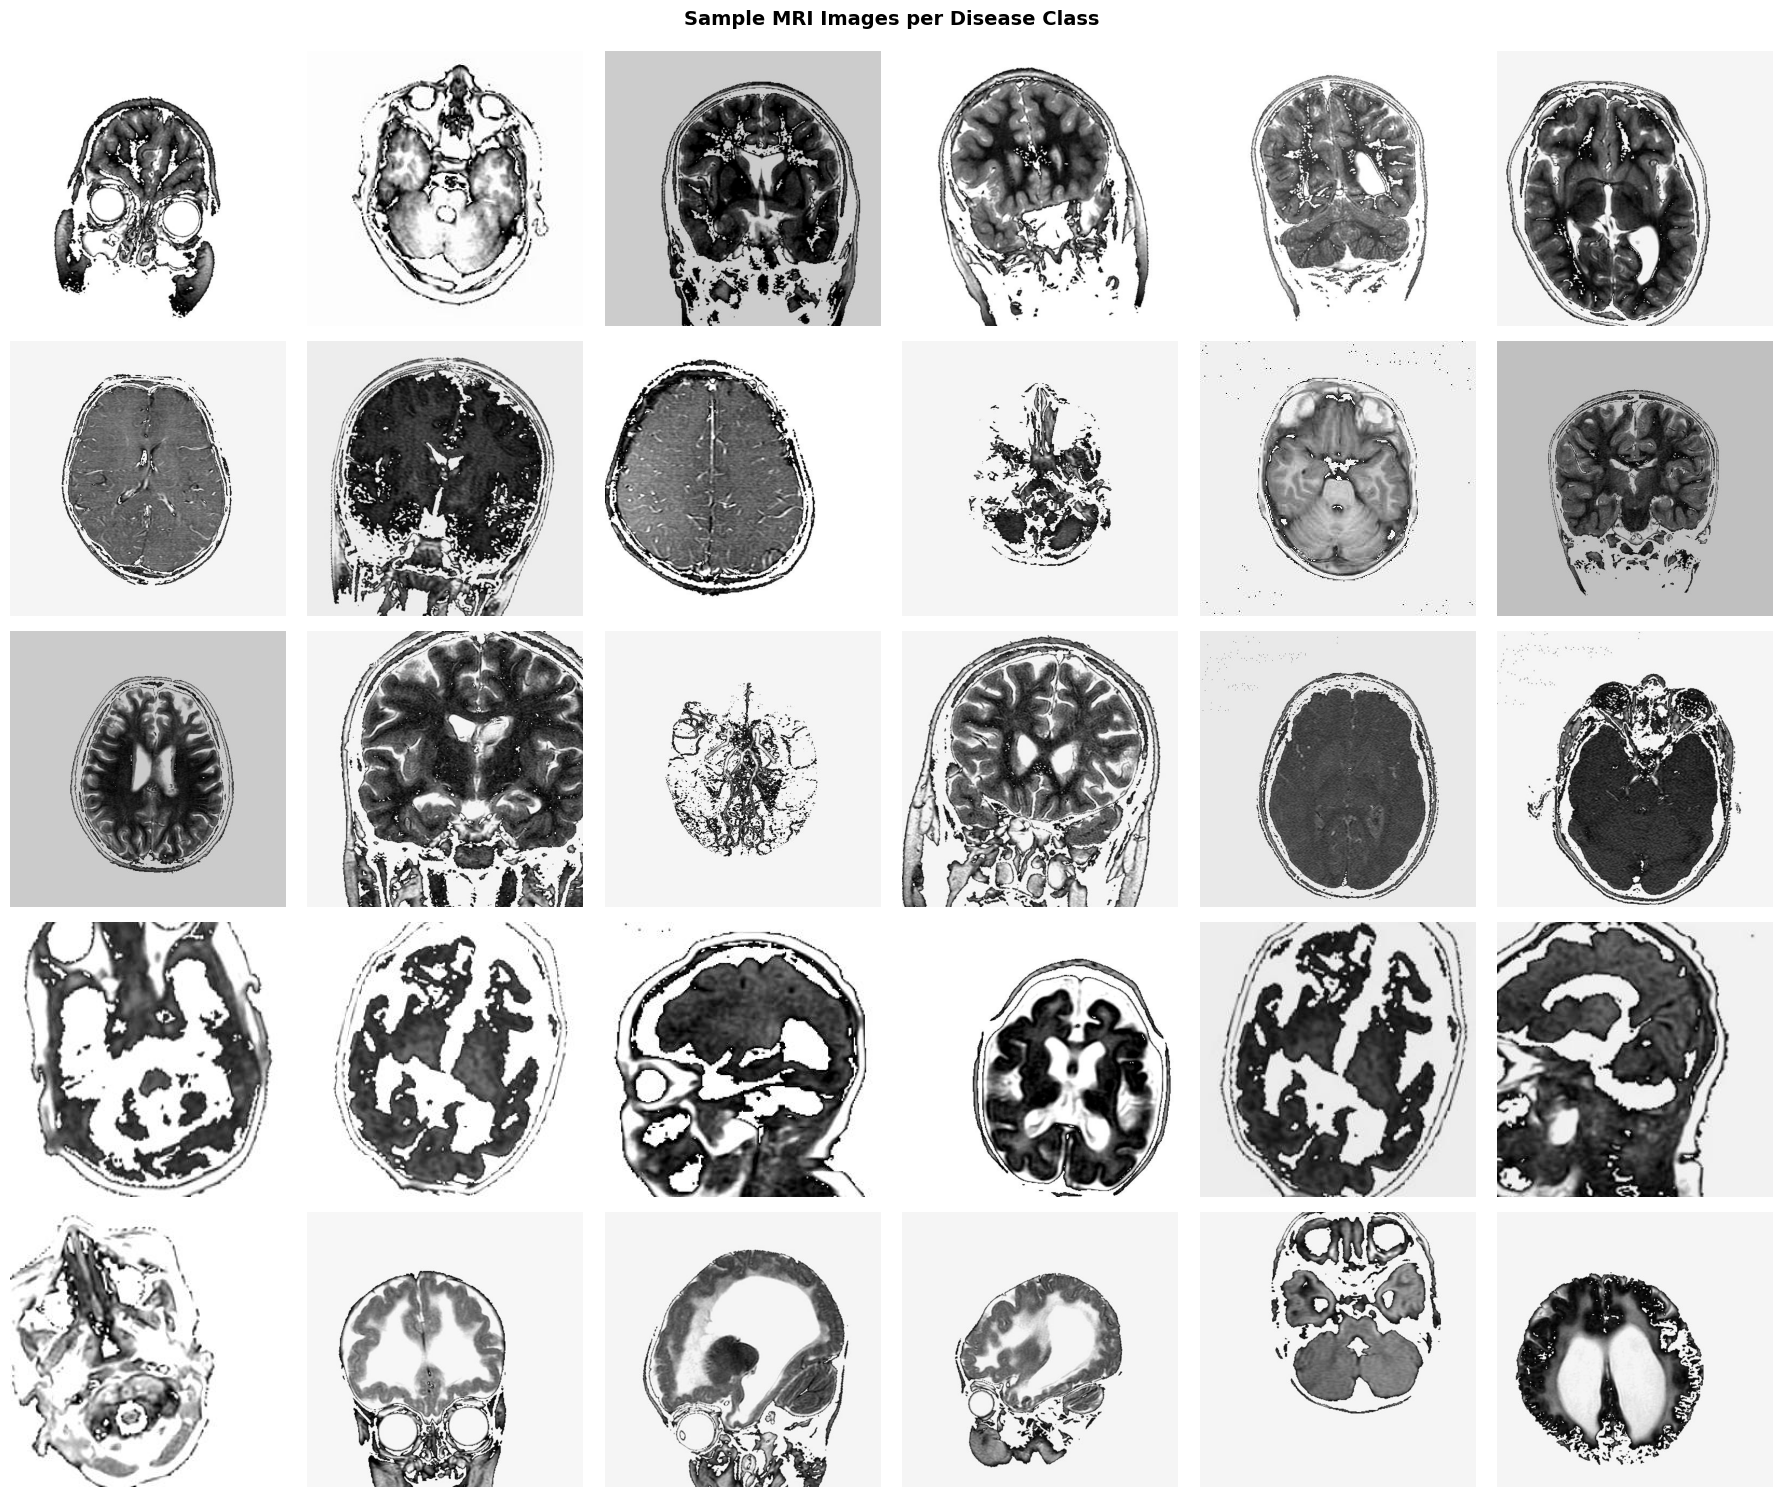

In [ ]:
# ---------------------------------------------------------
# Sample Grid Visualization
# ---------------------------------------------------------

def show_samples(n_per_class=4):
  # One subplot row per class, one column per requested sample
    fig, axes = plt.subplots(len(disease_classes), n_per_class,
                             figsize=(n_per_class*3, len(disease_classes)*3))
    train_path = os.path.join(DATASET_ROOT, 'train')

    for i, cls in enumerate(disease_classes):
        cls_path = os.path.join(train_path, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        # random.sample() draws WITHOUT replacement, so no duplicated tiles
        # min(...) protects against classes with fewer images than requested
        sampled = random.sample(images, min(n_per_class, len(images)))
        for j, img_name in enumerate(sampled):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            # cmap='gray' only when the file is single-channel ('L' mode)
            # RGB files must be shown without a colormap
            axes[i, j].imshow(img, cmap='gray' if img.mode == 'L' else None)
            axes[i, j].axis('off')
            if j == 0:
                '''CAVEAT: axis('off') above hides the whole axis, including its ylabel -
                so this class name is NOT rendered in the figure
                Use axes[i, j].set_title(cls) or ax.text(...) instead if the row labels are needed'''
                axes[i, j].set_ylabel(cls, fontsize=10, fontweight='bold',
                                      rotation=0, ha='right', va='center')

    plt.suptitle('Sample MRI Images per Disease Class', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(UTILS_DIR / "sample_grid.png", dpi=150, bbox_inches='tight')
    plt.show()

show_samples(6)

> *Sample MRI images per disease class*
>
> One row per disease, in canonical order (row 1 *fukuyama* ... row 5 *walker–warburg*).
>
> - **Planes are mixed inside each class** — axial, coronal and sagittal side by side, with both paediatric and adult heads; \
>   some tiles are orbital or skull-base sections rather than brain slices
> - The images are **not raw DICOM**: window-levelled and heavily contrast-stretched, which produces the saturated black/white regions
>   and the speckled skull outlines
> - **The rows also differ in rendering, not only in anatomy:** *pachygyria* is posterised into near-binary black and white,
>   *hallervorden–spatz* is flat and mid-grey, *moyamoya* is dark with background speckle \
>   Even the padding colour varies
>
> That last point is worth keeping in mind when reading the final accuracy: part of what separates these classes is
> **how the images were processed**, not only *what they show* \
> It applies equally to both notebooks, so it does not distort the comparison between the two strategies


## **4) Data transformation**

- Set the global seed (*`SEED = 33`*) so augmentation and subset draws are **reproducible**, and so notebook 02 works on exactly the same splits
- Build the datasets. *`build_dataloaders(..., return_train_eval=True)`* returns **two versions of the training split**: \
  *`train_ds`* with augmentation (*`aug_factor=2`*, used for training) and *`train_eval_ds`* without it \
  *Feature extraction* must use the second one — the frozen-backbone pipeline needs one fixed vector per image, \
  and augmented features would be random and duplicated
- Preview a few original / augmented pairs
- Build the DataLoaders (only used for inspection here; *`extract_features`* builds its own)


In [ ]:
# Global seed on notebook & dataset root
'''set_seed() seeds Python's random, NumPy and PyTorch in one call, so the augmentations,
the train/val sampling and the SVM tie-breaking are repeatable
Any change to SEED changes every stochastic result in the notebook
'''
SEED = 33
set_seed(SEED)

set_dataset_root(DATASET_ROOT)

Global dataset root set to: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated


In [ ]:
# Dataset initialization (Data Augmentation active only on train)
'''Arguments:
   img_size   = 224 -> ResNet-50's native input resolution (ImageNet standard)
   aug_factor = 2   -> each training image is yielded twice per epoch with different random
                        transforms, doubling the effective training set (1400 -> 2800 samples)
   classes          -> the canonical order returned by verify_dataset_structure()
   return_train_eval-> ALSO returns the training split with the deterministic val/test
                        transform and aug_factor=1

Passing the augmented train_ds to extract_features would give features that are random
(a new TorchIO draw at every call) and duplicated (aug_factor=2), and it would also inflate the
few-shot curve, since the real number of distinct images per class is half of n_per_class

train_ds keeps the augmentation and is used only where augmentation belongs'''
train_ds, val_ds, test_ds, train_eval_ds = build_dataloaders(
    dataset_root=DATASET_ROOT,
    batch_size=32,
    img_size=224,
    aug_factor=2,
    seed=SEED,
    return_train_eval=True,
    classes=disease_classes
)

print(f"train (augmented, aug_factor=2): {len(train_ds)} samples "
      f"({train_ds.n_unique_samples} distinct images)")
print(f"train (clean, for extraction):   {len(train_eval_ds)} samples")
print(f"val: {len(val_ds)} | test: {len(test_ds)}")
print(f"class_to_idx: {train_eval_ds.class_to_idx}")


train (augmented, aug_factor=2): 2800 samples (1400 distinct images)
train (clean, for extraction):   1400 samples
val: 300 | test: 300
class_to_idx: {'fukuyama_muscular_dystrophy': 0, 'hallervorden_spatz_disease': 1, 'moyamoya_disease': 2, 'pachygyria_cerebellar_hypoplasia': 3, 'walker_warburg_syndrome': 4}


> *Dataset initialization*
>
> - *`train (augmented): 2800 samples (1400 distinct images)`* — each image is yielded twice per epoch
>   under different random transforms
> - *`train (clean, for extraction): 1400 samples`* — the same images, deterministic, no duplication \
>   **This is the one the SVM path uses**
> - *`val: 300 | test: 300`*, un-augmented
> - *`class_to_idx`* matches the canonical order and is what ends up in the saved artifacts


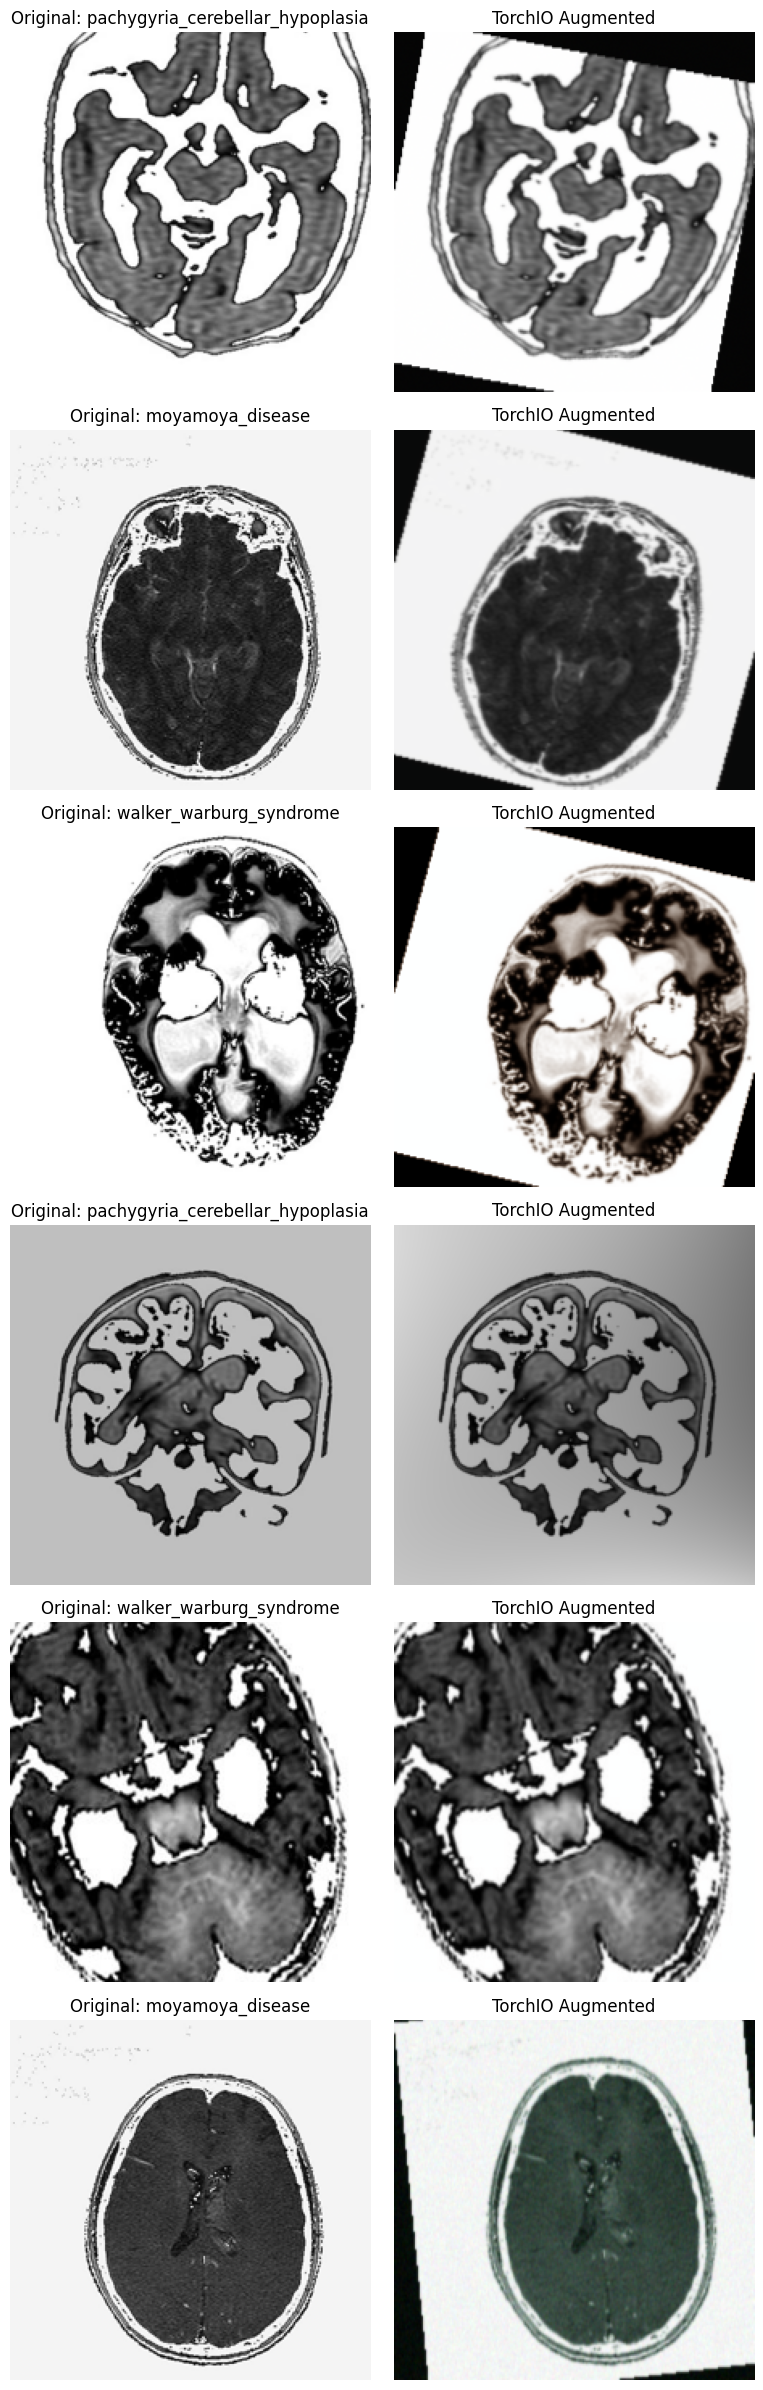

In [ ]:
# View some random examples to verify the quality of the transformations
''' original vs transformed pairs
Overly aggressive transforms (extreme rotation, intensity shifts that erase the lesion, flips that break left/right anatomy)
silently destroy the signal the model is supposed to learn
Same seed as above -> same samples every run'''

visualize_augmentations(train_ds, num_samples=6, seed=SEED)

> *Original vs. TorchIO-augmented samples*
>
> Six random training samples, original and augmented
>
> - **Rotation** (rows 1, 2, 3, 6): the tilted brain and the black corners left by zero-padding
> - **Bias field** (row 4): the smooth intensity gradient across the slice, simulating coil inhomogeneity \
>   — the domain-appropriate transform that justifies TorchIO over plain torchvision
> - **Gamma / intensity jitter** (rows 3, 5), and a colour cast in rows 3 and 6 (TorchIO draws an
>   independent bias field per channel, and the greyscale slice is carried as 3 channels)
>
> Anatomy stays recognisable in every pair and **no horizontal flips** are applied: left and right are not interchangeable in brain MRI \
> In this notebook the augmentation only affects *`train_ds`*, which the SVM path never touches \
> — it matters for notebook 02, where the network trains on these images

In [ ]:
# DataLoaders are not needed in this notebook: the frozen-backbone path works on feature
# matrices, and extract_features() builds its own loader internally
# They are kept only for quick manual inspection of a batch
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

## **5) ResNet-50 + SVM**

- **Feature extraction** — the frozen backbone maps each image to its 2048-D global-average-pooled embedding \
  Run on `train_eval_ds`, not `train_ds`
- **PCA & LDA visualization** — a purely diagnostic look at the embedding space, not part of the pipeline
- **SVM training** — tune *C* on validation, refit on train+val with `probability=True`, evaluate once on test


In [ ]:
# ---------------------------------------------------------
# Load Model & Feature Extraction
# ---------------------------------------------------------
'''Features are extracted from train_eval_ds, NOT from train_ds: the frozen-backbone
pipeline needs one deterministic 2048-D vector per physical image
extract_features() now refuses an augmented dataset outright, so the mistake cannot be made silently'''

extractor = get_resnet50_extractor(DEVICE)

x_train, y_train = extract_features(extractor, train_eval_ds, DEVICE, batch_size=64,
                                    desc="Extracting Train Features (no augmentation)")
x_val, y_val = extract_features(extractor, val_ds, DEVICE, batch_size=64,
                                desc="Extracting Val Features")
x_test, y_test = extract_features(extractor, test_ds, DEVICE, batch_size=64,
                                  desc="Extracting Test Features")

print(f"\nTrain features: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
assert x_train.shape[0] == train_eval_ds.n_unique_samples, "unexpected duplication"

features_dict = {
    "x_train.npy": x_train, "y_train.npy": y_train,
    "x_val.npy": x_val,     "y_val.npy": y_val,
    "x_test.npy": x_test,   "y_test.npy": y_test,
}
save_features(MODEL_DIR, features_dict)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]
Extracting Test Features: 100%|██████████| 5/5 [00:01<00:00,  3.08it/s]



Train features: (1400, 2048) | Val: (300, 2048) | Test: (300, 2048)

All features have been saved in: /content/drive/MyDrive/University/rare-neuro-mri/resnet models


> *ResNet-50 features*
>
> Shapes are as expected: train *`(1400, 2048)`*, val *`(300, 2048)`*, test *`(300, 2048)`*  \
> *1400* rows, not *2800*, confirming the non-augmented dataset was used; the frozen-backbone pipeline needs one fixed vector per image \
> The *2048* columns are the global-average-pooled output of the last residual stage, \
> obtained by replacing *`model.fc`* with *`nn.Identity()`*
>
> In this run the matrices were reloaded from the *`.npy`* files saved on Drive by the previous
> execution, rather than re-extracted (the extraction cell above was not run) \
> The *ImageNet* checkpoint is still downloaded, because the backbone object itself is needed to save the weights at the end; but no image is processed \
> The output of the SVM cell is bit-identical to the run that produced those *`.npy`* files: same tuning grid, same test accuracy, same few-shot table


### **a) PCA Visualization**

PCA projects the *2048-dimensional embedding space* onto **2 dimensions**, as a first, cheap look at *how separable* the five conditions are before any classifier is fitted

PCA maximises variance, so without it the dimensions with the largest numeric range would dominate the components regardless of how informative they are

The plot is **unsupervised** — it maximises variance, not class separation — so overlap in the scatter is weak evidence about classifiability, while clean
separation would be strong evidence


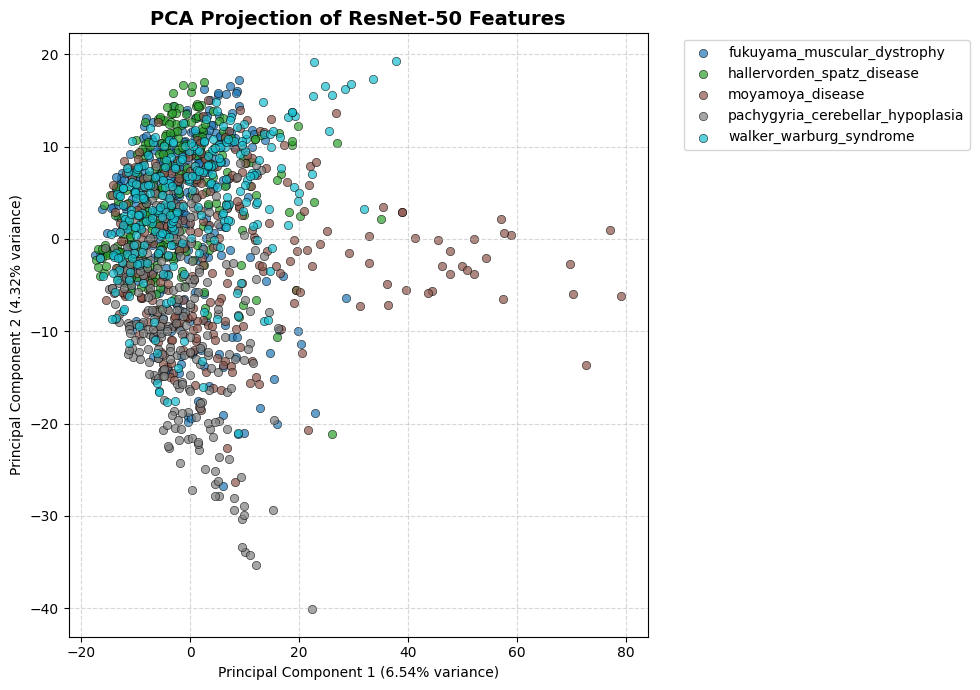

In [ ]:
# ---------------------------------------------------------
# PCA Visualization
# ---------------------------------------------------------

def plot_pca_features(X, y, class_names, title="PCA Projection of ResNet-50 Features"):
    # Pre-normalization (fundamental for PCA)

    # StandardScaler puts every one of the 2048 dimensions at mean 0, std 1
    X_scaled = StandardScaler().fit_transform(X)

    # Reduction to 2 principal components
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X_scaled)

    # Share of the total variance captured by each component, in percent
    var_exp = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(10, 7))
    # A qualitative colormap sampled at len(class_names) discrete colors
    colors = plt.colormaps["tab10"].resampled(len(class_names))

    # One scatter() call per class so that each gets its own legend entry
    for i, cls in enumerate(class_names):
        mask = (y == i)         # boolean mask selecting this class's rows
        plt.scatter(
            X_pca[mask, 0],      # PC1 coordinate
            X_pca[mask, 1],      # PC2 coordinate
            label=cls,
            alpha=0.7,           # transparency reveals point density
            edgecolors='k',
            linewidths=0.5,
            c=[colors(i)]        # wrapped in a list: one RGBA tuple, not a value list
        )

    # Axis labels carry the explained variance
    plt.xlabel(f"Principal Component 1 ({var_exp[0]:.2f}% variance)")
    plt.ylabel(f"Principal Component 2 ({var_exp[1]:.2f}% variance)")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')   # legend outside the axes
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Perform PCA visualization on the training set
plot_pca_features(x_train, y_train, disease_classes)

> *PCA Projection of ResNet-50 Features*
>
> The **1400 training embeddings** (*280* per class, one deterministic vector per physical image) \
> are plotted, standardised and projected onto the first 2 principal components
>
> **What this plot shows**
> - **PC1 + PC2 explain only 6.54 % + 4.32 % = 10.86 % of the total variance** \
>   Roughly *89%* of the information sits in the discarded directions, so this scatter do not show information about the class separability
> - The bulk of the data is **one dense overlapping cloud** on the left, with no visually separable
>   clusters — yet the SVM reaches *98.7%* on the same features \
>   The SVM works in the full *2048-D space*, where a hyperplane can exploit directions PC1 and PC2 simply do not show
> - **Two class-associated tails are visible**, \
>   The long right-hand spread along PC1 (up to *~80*) is populated almost exclusively by *moyamoya* (brown), \
>   and the downward tail along PC2 (to *~-40*) almost exclusively by *pachygyria* (grey) \
>   So the single largest direction of variance in the embedding space is partly **class-correlated** —
>   From this it is possible to deduce that the PC1 is the kind of axis a brightness/contrast difference would produce

### **b) LDA Visualization**

PCA is *unsupervised*: it maximises variance, and most of the variance here encodes nuisance factors
(*acquisition plane, brightness, head size*) rather than pathology — which is why its scatter is one
overlapping cloud. \
LDA wants to know which directions maximise **between-class**
scatter relative to **within-class** scatter. \
With 5 classes it yields at most 4 discriminant directions; the first 2 are plotted.

**Two factors to keep in mind**

1. **PCA to 50 dimensions first:** \
   With *1400* samples and *2048* features the within-class scatter matrix
   is singular and LDA overfits: on *random labels* at this exact shape it reaches ***0.95*** train accuracy against *0.24* on test. \
   After PCA(50) the same control gives *0.32*. \
   Without this reduction, the plot would show five clean clusters even on pure noise
2. **Fit on train, plot train *and* test.** LDA is supervised, so the left panel is what it was
   optimised to produce and is a sanity check, not evidence. \
   **The held-out panel is the result**: if the two look alike the separation is real, if only the left one is clean the projection is overfitted

Diagnostic only: nothing here feeds the classifier.


PCA(50) retains 52.7% of the total variance
LD1 and LD2 carry 77.2% of the between-class variance
LDA classifier accuracy   train: 0.9014 | test: 0.8833
Separation (between/within scatter)  train: 4.17 | test: 3.94
  -> the test value is the informative one; a large drop would mean the training projection is overfitted


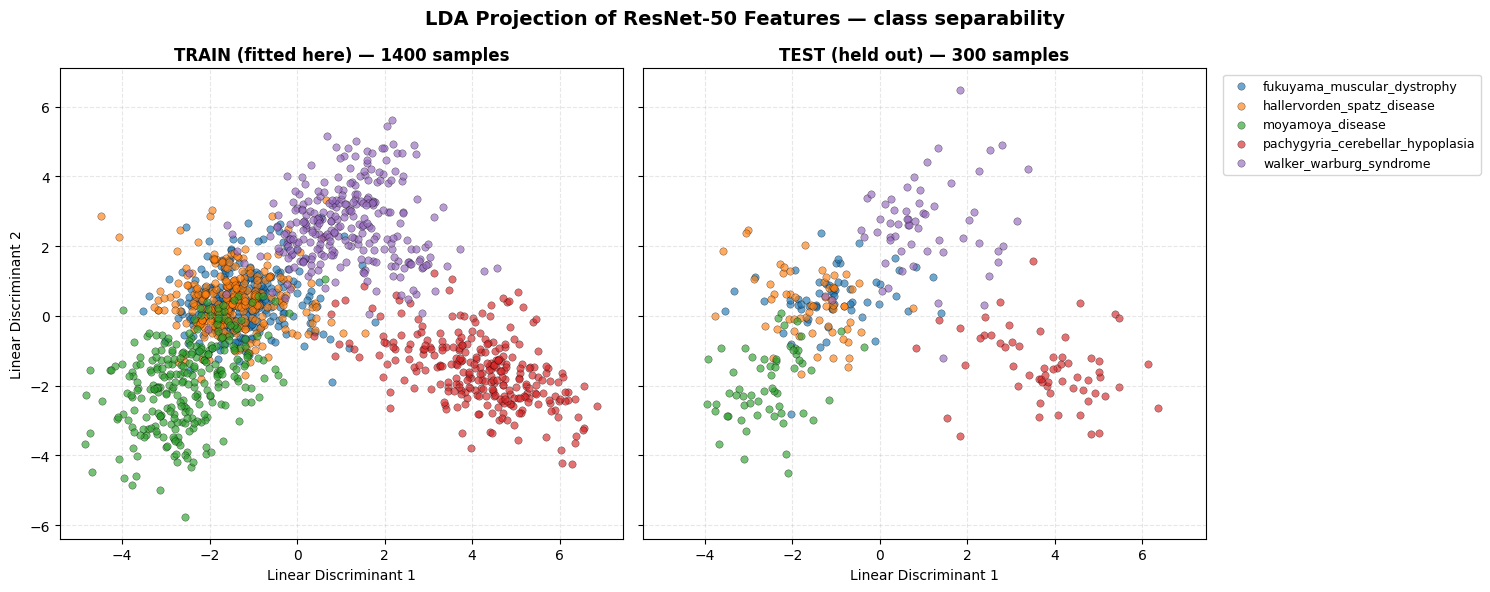

In [ ]:
# ---------------------------------------------------------
# LDA projection - supervised view of class separability
# ---------------------------------------------------------
'''PCA(50) first, because LDA on 2048-D with 1400 samples overfits (0.95 train / 0.24 test on random labels)
Fitted on train; both panels plotted, since only the held-out one is evidence'''

import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

N_PCA = 50

# Everything is fitted on TRAIN only; val/test are merely transformed
scaler_lda = StandardScaler().fit(x_train)
pca_lda = PCA(n_components=N_PCA, random_state=SEED).fit(scaler_lda.transform(x_train))

Xtr_p = pca_lda.transform(scaler_lda.transform(x_train))
Xte_p = pca_lda.transform(scaler_lda.transform(x_test))

lda = LinearDiscriminantAnalysis(n_components=2).fit(Xtr_p, y_train)
Ztr, Zte = lda.transform(Xtr_p), lda.transform(Xte_p)

print(f"PCA({N_PCA}) retains {pca_lda.explained_variance_ratio_.sum():.1%} of the total variance")
print(f"LD1 and LD2 carry {lda.explained_variance_ratio_[:2].sum():.1%} of the between-class variance")
print(f"LDA classifier accuracy   train: {lda.score(Xtr_p, y_train):.4f} | "
      f"test: {lda.score(Xte_p, y_test):.4f}")


def between_within(Z, y):
    """Between-class over within-class scatter on the 2-D projection: higher = better separated."""
    m = Z.mean(axis=0)
    b = sum(((Z[y == c].mean(axis=0) - m) ** 2).sum() * (y == c).sum() for c in np.unique(y))
    w = sum(((Z[y == c] - Z[y == c].mean(axis=0)) ** 2).sum() for c in np.unique(y))
    return b / w


ratio_tr, ratio_te = between_within(Ztr, y_train), between_within(Zte, y_test)
print(f"Separation (between/within scatter)  train: {ratio_tr:.2f} | test: {ratio_te:.2f}")
print(f"  -> the test value is the informative one; a large drop would mean the training "
      f"projection is overfitted")

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
for ax, Z, y, title in [(axes[0], Ztr, y_train, f"TRAIN (fitted here) — {len(y_train)} samples"),
                        (axes[1], Zte, y_test, f"TEST (held out) — {len(y_test)} samples")]:
    for idx, cls in enumerate(disease_classes):
        mask = (y == idx)
        ax.scatter(Z[mask, 0], Z[mask, 1], s=28, alpha=0.65,
                   edgecolors='black', linewidths=0.3, label=cls)
    ax.set_xlabel('Linear Discriminant 1')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

axes[0].set_ylabel('Linear Discriminant 2')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.suptitle('LDA Projection of ResNet-50 Features — class separability',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(UTILS_DIR / "lda_projection_resnet50.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

> *LDA Projection of ResNet-50 Features*
>
> The same **1400 training embeddings**, reduced to *50* principal components and then projected onto the first 2 **discriminant** directions \
> *Left panel fitted, right panel held out*
>
> ***The projection is trustworthy***
> - **Actual separation:** The LDA accuracy gap between the training (90.1%) and test (88.3%) sets is just 1.8 points, confirming the absence of overfitting (unlike the random-label control)
> - **Representativeness:** By reducing the features to 50 PCA components, the first two LDA axes (LD1 and LD2) capture 77.2% of the between-class variance, providing an extremely informative 2D view
>
> ***Interpretation of Clusters***
> - **Separate groups:** *Moyamoya*, *pachygyria*, and *Walker-Warburg* form distinct clusters
> - **The only overlap:** *Fukuyama* and *Hallervorden-Spatz* overlap at the center. This is the only complex pair involving a linear boundary, and it exactly mirrors the main errors observed in the confusion matrix
>
>***Key finds***
> - **LDA vs. PCA:** Visually explains why linear SVM achieves 98.67% accuracy \
> The class structure exists; it simply does not lie along the directions of maximum variance visible with PCA
> - **Lower bound:** The LDA accuracy (88.3%) operates in a space reduced to 50 dimensions; it serves as a supporting visualization, not as a maximum measure of separability


> *Note on preprocessing:* \
> clean separation demonstrates that the data are distinguishable within the ResNet-50 embedding, but it does not rule out the possibility that part of the difference stems from preprocessing artifacts rather than anatomical features


### **c) SVM training on the full dataset**

A single call to *`train_svm_classifier`*:

1. **Tune C on validation.** *C* is the regularization trade-off: \
   **small *C*** = wide margin and more tolerated violations, \
   **large *C*** = harder fit to every training point \
   Ties keep the smallest *C*
2. **Refit on train+val** with *`probability=True`*, so the SVM exposes *`predict_proba`* — without it the
   API cannot return the probability distribution over the five classes
3. **Evaluate once on test**

*`class_names`* and the fitted *`scaler`* are saved with the model: the SVM only sees integer labels, and a
new image must be standardised with the training statistics.


In [ ]:
# ---------------------------------------------------------
# SVM tuning + final training on train+val + test evaluation
# ---------------------------------------------------------

svm_artifacts, test_preds, test_proba = train_svm_classifier(
    X_train=x_train, y_train=y_train,
    X_val=x_val,     y_val=y_val,
    X_test=x_test,   y_test=y_test,
    class_names=disease_classes,
    seed=SEED
)

print("\nDetailed Report:")
print(classification_report(y_test, test_preds, target_names=disease_classes, digits=4))

# The probability distribution the API has to return
print(f"\npredict_proba shape: {test_proba.shape} "
      f"(rows sum to 1: {np.allclose(test_proba.sum(axis=1), 1.0)})")
print(f"Mean confidence on the predicted class: {test_proba.max(axis=1).mean():.4f}")


Tuning C on the validation set:
  C=  0.01 | Val Acc: 0.9867 | Val Macro-F1: 0.9867
  C=  0.10 | Val Acc: 0.9867 | Val Macro-F1: 0.9867
  C=  1.00 | Val Acc: 0.9867 | Val Macro-F1: 0.9867
  C= 10.00 | Val Acc: 0.9867 | Val Macro-F1: 0.9867
  C=100.00 | Val Acc: 0.9867 | Val Macro-F1: 0.9867
Best C: 0.01
Final SVM fitted on 1700 samples (train+val).

Detailed Report:
                                  precision    recall  f1-score   support

     fukuyama_muscular_dystrophy     0.9672    0.9833    0.9752        60
      hallervorden_spatz_disease     1.0000    0.9667    0.9831        60
                moyamoya_disease     0.9836    1.0000    0.9917        60
pachygyria_cerebellar_hypoplasia     1.0000    1.0000    1.0000        60
         walker_warburg_syndrome     0.9833    0.9833    0.9833        60

                        accuracy                         0.9867       300
                       macro avg     0.9868    0.9867    0.9867       300
                    weighted avg     

> *SVM tuning and final test evaluation*
>
> - **The validation grid is flat**: all five values of *C*, across four orders of magnitude, give the same 0.9867 \
>   The classes are close to linearly separable in the embedding space, so the regularization is not the binding constraint \
>   *`Best C: 0.01`* is a tie-break (widest margin among equally-performing models), not a real selection
> - **Test accuracy 0.9867** (*296/300*, *4* errors); macro-F1 and weighted-F1 identical, as the balanced test set implies \
>   With *300* images the *95%* confidence interval is roughly **[96.6%, 99.5%]**
> - **Mean confidence** on the predicted class is *0.9688* against *0.9867* **accuracy** — very slightly under-confident
>*The SVM stage carries no hidden randomness beyond the fixed seed*


## **6) Metrics, plots and few-shot robustness**

- *`evaluate_and_save_all`* prints the metrics, saves the confusion matrix and the per-class chart, runs the few-shot study, and writes the results JSON and the artifacts pickle

- **The few-shot study is valid** because the backbone is frozen and never saw the labels: \
the features are fixed, so shrinking the SVM's training set simulate data scarcity

- *`run_fewshot_analysis()`* runs with its defaults and records neither of them, so the settings behind the curve (*`fewshot_sizes`*, *`n_runs`*, and a one-line description of the protocol) are written into the artifacts explicitly after the call


 EVALUATION RESULTS: RESNET50_SVM
Test Accuracy:     0.9867
Test Macro-F1:     0.9867
Test Weighted-F1:  0.9867

Detailed Classification Report:
                                  precision    recall  f1-score   support

     fukuyama_muscular_dystrophy     0.9672    0.9833    0.9752        60
      hallervorden_spatz_disease     1.0000    0.9667    0.9831        60
                moyamoya_disease     0.9836    1.0000    0.9917        60
pachygyria_cerebellar_hypoplasia     1.0000    1.0000    1.0000        60
         walker_warburg_syndrome     0.9833    0.9833    0.9833        60

                        accuracy                         0.9867       300
                       macro avg     0.9868    0.9867    0.9867       300
                    weighted avg     0.9868    0.9867    0.9867       300



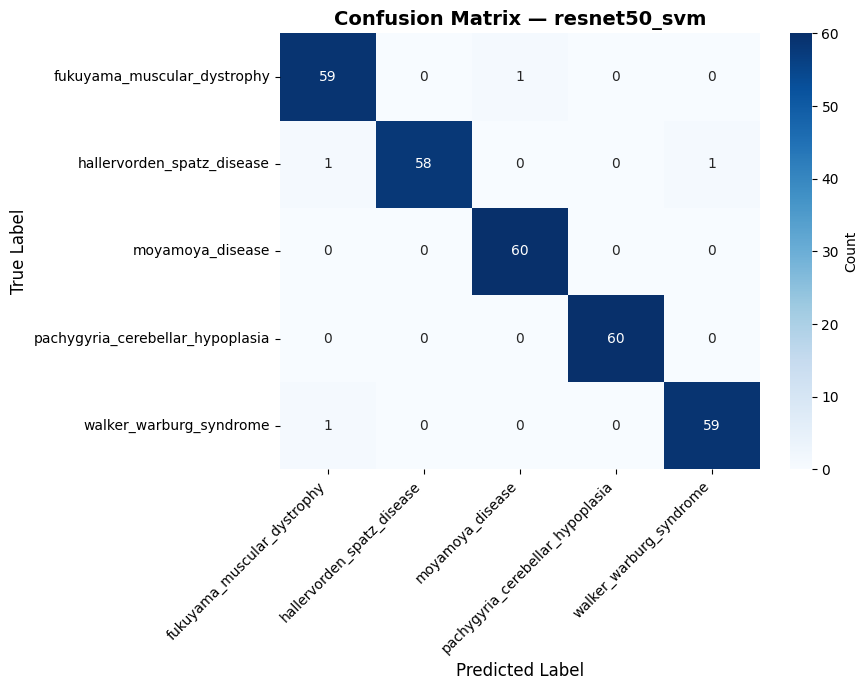

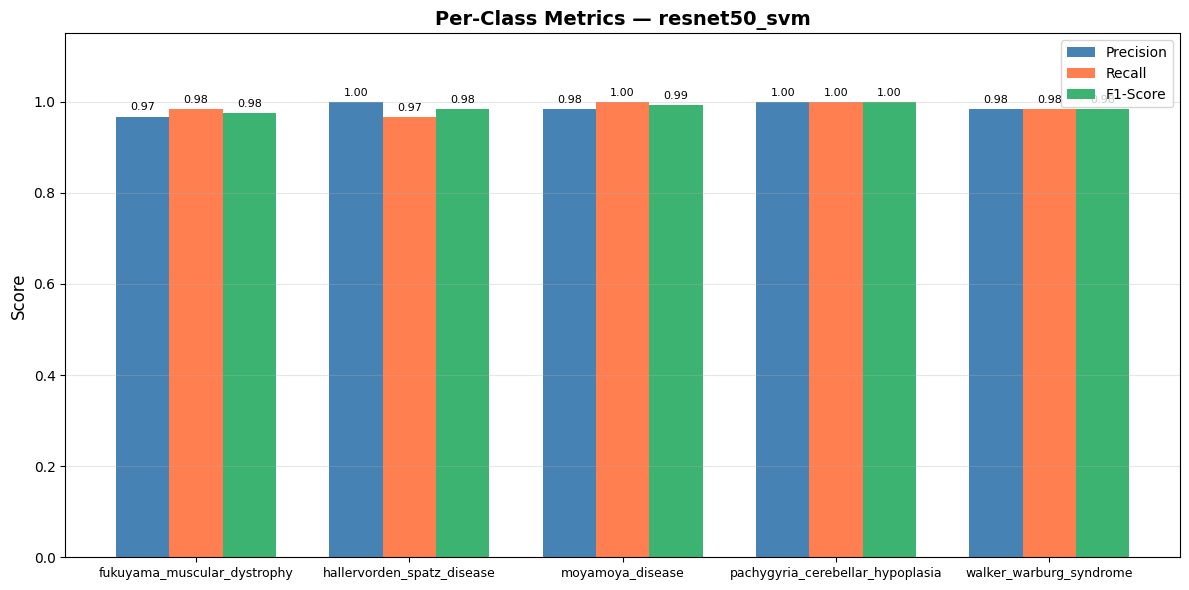


Running few-shot experiments...


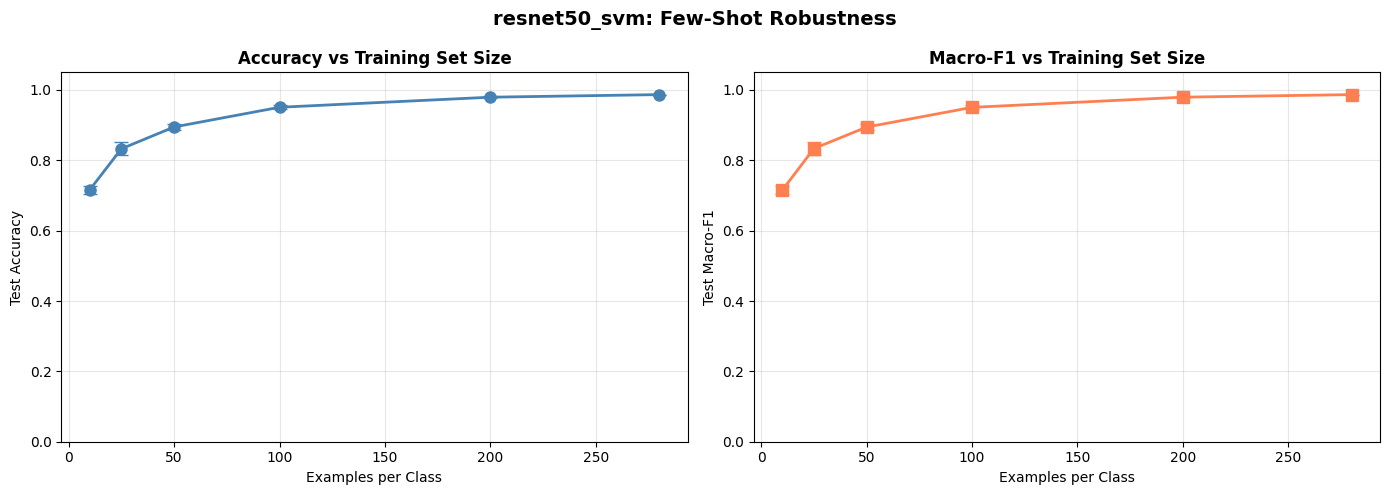

 n_per_class  acc_mean  acc_std  f1_mean   f1_std
          10  0.716000 0.011035 0.714807 0.011144
          25  0.832667 0.018062 0.833269 0.018416
          50  0.894667 0.008055 0.894341 0.008218
         100  0.950667 0.005735 0.950419 0.005859
         200  0.979333 0.002494 0.979385 0.002516
         280  0.986667 0.000000 0.986665 0.000000

 Output saved:
  - Graphs saved in: /content/drive/MyDrive/University/rare-neuro-mri/resnet utils
  - Artifacts and Weights saved in: /content/drive/MyDrive/University/rare-neuro-mri/resnet models
Few-shot settings recorded in the artifacts.


In [ ]:
# ---------------------------------------------------------
# Metrics, plots, few-shot analysis and artifact saving
# ---------------------------------------------------------

evaluate_and_save_all(
    y_true=y_test,
    y_pred=test_preds,
    class_names=disease_classes,
    utils_dir=UTILS_DIR,
    model_dir=MODEL_DIR,
    model_name="resnet50_svm",
    X_train_feats=x_train,
    y_train_labels=y_train,
    X_test_feats=x_test,
    C=svm_artifacts['best_C'],
    artifacts_to_save=svm_artifacts,
    torch_model_to_save=extractor,   # frozen ResNet-50 backbone (fc = Identity)
    seed=SEED
)

# run_fewshot_analysis() uses its defaults and records neither of them, so the
# settings behind the curve are written into the artifacts explicitly
svm_artifacts['fewshot_protocol'] = "frozen ResNet-50 features, linear SVM refitted on each subset"
svm_artifacts['fewshot_sizes'] = [10, 25, 50, 100, 200]
svm_artifacts['fewshot_n_runs'] = 5

import pickle
with open(MODEL_DIR / "resnet50_svm_artifacts.pkl", 'wb') as f:
    pickle.dump(svm_artifacts, f)
print("Few-shot settings recorded in the artifacts.")

> ***Confusion matrix*** \
> Two classes are perfect (*moyamoya* and *pachygyria*, *60/60*) \
> The four errors: \
> - *fukuyama* → 1 *moyamoya*
> - *hallervorden-spatz* → 1 *fukuyama* and 1 *walker-warburg*
> - *walker-warburg* → 1 *fukuyama*
>
> The *fukuyama ↔ walker-warburg* confusion is the clinically plausible one — both are congenital muscular dystrophies with cobblestone lissencephaly and overlapping MRI appearance \
> With only *4 errors*, which specific pairs get confused would likely change with a different seed

---

> ***Per-class metrics***
>
> | class | precision | recall | F1 |
> |---|---|---|---|
> | fukuyama_muscular_dystrophy | 0.967 | 0.983 | 0.975 |
> | hallervorden_spatz_disease | 1.000 | 0.967 | 0.983 |
> | moyamoya_disease | 0.984 | 1.000 | 0.992 |
> | pachygyria_cerebellar_hypoplasia | 1.000 | 1.000 | 1.000 |
> | walker_warburg_syndrome | 0.983 | 0.983 | 0.983 |
>
> Every value sits between *0.96* and *1.00*, so no class is sacrificed for the average
> - *fukuyama* has the lowest precision (it attracts the stray predictions),
> - *hallervorden–spatz* the lowest recall (it only loses cases)
>
> Macro and weighted averages coincide because the test set is balanced

---

> ***Few-shot robustness***
>
> | examples/class | accuracy | std | macro-F1 |
> |---|---|---|---|
> | 10 | 0.7160 | 0.0110 | 0.7148 |
> | 25 | 0.8327 | 0.0181 | 0.8333 |
> | 50 | 0.8947 | 0.0081 | 0.8943 |
> | 100 | 0.9507 | 0.0057 | 0.9504 |
> | 200 | 0.9793 | 0.0025 | 0.9794 |
> | 280 (full) | 0.9867 | 0.0000 | 0.9867 |
>
> Five random subsets per size; the error bars are the standard deviation across those draws
>
> - **A classic logarithmic learning curve:** Accuracy rises rapidly up to *~100* examples per class (*95.1%*) and then plateaus. \
>   Between *200* and *280* examples, the gain is only *+0.7* points, approaching saturation
> - **Excellent results with limited data:** With just *10* examples per class, the model achieves *71.6%* **accuracy** (compared to *20%* for random guessing) \
>    *This serves as key evidence of the effectiveness of the frozen-backbone approach for rare diseases*
> - **Reduction in uncertainty:** The standard deviation (*`std`*) drops sharply from *0.018* to *0.0025* as the amount of data increases \
>    Beyond *50* examples, the error bars become almost invisible, making the estimates extremely stable
>
> The final value of *98.67%* (based on *280* examples) comes from a single run (*`std 0.0`*) that includes both the training and validation sets (approximately *340* actual examples per class) \
> *It is therefore slightly more optimistic than the general trend of the curve*

---

## **7) Notes on the results**

On this dataset, frozen ResNet-50 features with a linear SVM reach
**98.67% test accuracy** and retain **71.6%** with only *10* labelled examples per class \
The test set is scored exactly once, *C* is tuned on validation only, and the features are
deterministic, so nothing leaks between model selection and evaluation.

**Some considerations**
- With 300 test images and 4 errors, differences of one or two images are noise
- The five classes differ in preprocessing style as well as in anatomy (see the sample grid), so these
  figures measure separability *on this dataset as distributed* rather than diagnostic performance \
  This affects both strategies equally and therefore does not distort the comparison

**Next:** run `02_convnext-tiny_ft.ipynb` and compare the two few-shot curves. \
The interesting question
is not *which model wins with all the data*, but *which degrades more gracefully when data runs out* — the
regime that actually describes **rare diseases**.
